In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns




df = pd.read_csv("patient_data.csv")

print("Shape of dataset:", df.shape)
print("First 5 rows:")
print(df.head())




print("\nData types:")
print(df.dtypes)

print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nTarget column value counts:")
print(df["readmitted"].value_counts())

Shape of dataset: (101766, 25)
First 5 rows:
   time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
0                 1                  41               0                1   
1                 3                  59               0               18   
2                 2                  11               5               13   
3                 2                  44               1               16   
4                 1                  51               0                8   

   number_outpatient  number_emergency  number_inpatient  number_diagnoses  \
0                  0                 0                 0                 1   
1                  0                 0                 0                 9   
2                  2                 0                 1                 6   
3                  0                 0                 0                 7   
4                  0                 0                 0                 5   

   gender             race  .

In [16]:
# DROP COLUMNS WITH TOO MANY MISSING VALUES


# A1Cresult has 83% missing values
# max_glu_serum has 95% missing values
# These columns are mostly empty so we just remove them

df = df.drop(columns=["A1Cresult", "max_glu_serum"])

print("\nAfter dropping high-missing columns:", df.shape)


# These are just ID codes and don't carry useful information for prediction
df = df.drop(columns=["admission_type_id", "discharge_disposition_id", "admission_source_id"])

print("After dropping admin columns:", df.shape)



# Race has only 2273 missing values (about 2%)
# We fill it with the most common value (mode)

most_common_race = df["race"].mode()[0]
df["race"] = df["race"].fillna(most_common_race)

print("\nMissing values in race after filling:", df["race"].isnull().sum())



After dropping high-missing columns: (101766, 23)
After dropping admin columns: (101766, 20)

Missing values in race after filling: 0


In [6]:


# Age is stored as a bracket like "[70-80)"
# We map each bracket to the lower number so the model can use it

age_mapping = {
    "[0-10)"  : 0,
    "[10-20)" : 10,
    "[20-30)" : 20,
    "[30-40)" : 30,
    "[40-50)" : 40,
    "[50-60)" : 50,
    "[60-70)" : 60,
    "[70-80)" : 70,
    "[80-90)" : 80,
    "[90-100)": 90
}

df["age"] = df["age"].map(age_mapping)

print("\nAge column after mapping:")
print(df["age"].value_counts().sort_index())



# Insulin has 4 categories that represent how much insulin the patient uses
# We convert them to numbers: No=0, Down=1, Steady=2, Up=3

insulin_mapping = {
    "No"    : 0,
    "Down"  : 1,
    "Steady": 2,
    "Up"    : 3
}

df["insulin"] = df["insulin"].map(insulin_mapping)

print("\nInsulin column after mapping:")
print(df["insulin"].value_counts())



# diabetesMed and change columns only have Yes or No
# We convert Yes to 1 and No to 0

df["diabetesMed"] = df["diabetesMed"].map({"Yes": 1, "No": 0})
df["change"]      = df["change"].map({"Ch": 1, "No": 0})

print("\ndiabetesMed value counts:")
print(df["diabetesMed"].value_counts())



df["gender"] = df["gender"].map({"Male": 1, "Female": 0})

print("\nGender after encoding:")
print(df["gender"].value_counts())




Age column after mapping:
age
0       161
10      691
20     1657
30     3775
40     9685
50    17256
60    22482
70    26066
80    17197
90     2793
Name: count, dtype: int64

Insulin column after mapping:
insulin
0    47380
2    30849
1    12218
3    11316
Name: count, dtype: int64

diabetesMed value counts:
diabetesMed
1    78361
0    23402
Name: count, dtype: int64

Gender after encoding:
gender
0    54708
1    47055
Name: count, dtype: int64


In [7]:

# Instead of keeping 5 separate drug columns we just count
# how many drugs each patient is actively taking

med_columns = ["metformin", "glipizide", "glyburide", "pioglitazone", "rosiglitazone"]

# Any value other than "No" means the patient is taking that drug
df["total_meds_active"] = 0

for col in med_columns:
    df["total_meds_active"] = df["total_meds_active"] + (df[col] != "No").astype(int)

# Now we can drop the original 5 columns
df = df.drop(columns=med_columns)

print("\ntotal_meds_active value counts:")
print(df["total_meds_active"].value_counts().sort_index())



# Patients who stay longer and visit more often are generally sicker
# We add up 4 related columns into one score

df["service_intensity"] = (df["time_in_hospital"] +
                           df["number_inpatient"]  +
                           df["number_outpatient"] +
                           df["number_emergency"])

print("\nservice_intensity sample values:")
print(df["service_intensity"].describe())




total_meds_active value counts:
total_meds_active
0    59169
1    29948
2    10907
3     1706
4       32
5        1
Name: count, dtype: int64

service_intensity sample values:
count    101763.000000
mean          5.598813
std           3.820593
min           1.000000
25%           3.000000
50%           5.000000
75%           7.000000
max          82.000000
Name: service_intensity, dtype: float64


In [8]:


# Race has 5 different categories so we create a separate column for each
# drop_first=True removes one column to avoid redundancy

df = pd.get_dummies(df, columns=["race"], drop_first=True)

print("\nColumns after encoding race:")
print(df.columns.tolist())



# Original target had 3 values: NO, >30, <30
# We want to predict: was the patient readmitted in less than 30 days?
# So we make it binary:
#   1 = readmitted in less than 30 days (this is what we want to detect)
#   0 = not readmitted within 30 days (includes NO and >30)

df["readmitted"] = (df["readmitted"] == "<30").astype(int)

print("\nTarget column after binary encoding:")
print(df["readmitted"].value_counts())
print("Percentage of positive class:", round(df["readmitted"].mean() * 100, 2), "%")




Columns after encoding race:
['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'gender', 'age', 'diabetesMed', 'change', 'insulin', 'readmitted', 'total_meds_active', 'service_intensity', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Other']

Target column after binary encoding:
readmitted
0    90406
1    11357
Name: count, dtype: int64
Percentage of positive class: 11.16 %


In [9]:


X = df.drop(columns=["readmitted"])   # all columns except the target
y = df["readmitted"]                  # only the target column

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)



# 80% of data goes to training, 20% goes to testing
# stratify=y makes sure both sets have the same % of positive class

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size   = 0.20,
    random_state= 42,
    stratify    = y
)

print("\nTraining set size:", X_train.shape)
print("Test set size    :", X_test.shape)



# StandardScaler makes all numbers have similar range
# This helps the model treat all features equally

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)   # fit on train, then transform
X_test  = scaler.transform(X_test)        # only transform test (no fitting)



Feature matrix shape: (101763, 19)
Target shape: (101763,)

Training set size: (81410, 19)
Test set size    : (20353, 19)


In [10]:

rf_model = RandomForestClassifier(
    n_estimators = 100,
    max_depth    = 10,
    class_weight = "balanced",
    random_state = 42,
    n_jobs       = -1
)

# Train the model
rf_model.fit(X_train, y_train)

print("\nModel training complete!")



y_pred      = rf_model.predict(X_test)          # predicted class labels
y_pred_prob = rf_model.predict_proba(X_test)[:, 1]  # probability of class 1

print("\nFirst 10 predictions:", y_pred[:10])




Model training complete!

First 10 predictions: [0 0 0 1 1 0 1 1 0 0]



========== MODEL EVALUATION ==========
Accuracy  : 0.6873
F1 Score  : 0.2572
Precision : 0.1750
Recall    : 0.4852
ROC-AUC   : 0.6469

Detailed Classification Report:
                     precision    recall  f1-score   support

 Not Readmitted (0)       0.92      0.71      0.80     18082
Readmitted <30d (1)       0.17      0.49      0.26      2271

           accuracy                           0.69     20353
          macro avg       0.55      0.60      0.53     20353
       weighted avg       0.83      0.69      0.74     20353



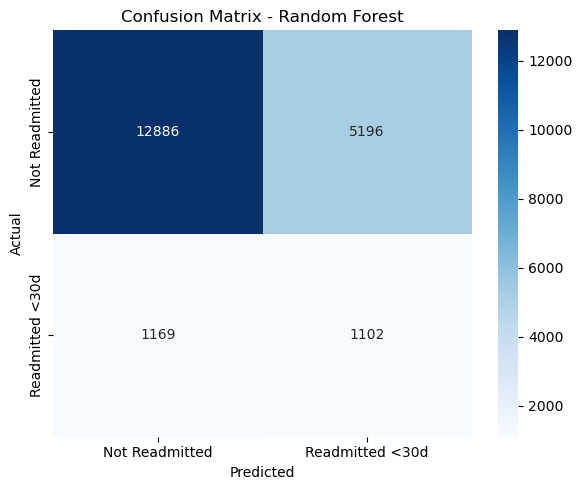

Confusion matrix saved!


In [11]:


accuracy  = accuracy_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
auc       = roc_auc_score(y_test, y_pred_prob)

print("\n========== MODEL EVALUATION ==========")
print(f"Accuracy  : {accuracy:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred,
                             target_names=["Not Readmitted (0)", "Readmitted <30d (1)"]))



cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Readmitted", "Readmitted <30d"],
            yticklabels=["Not Readmitted", "Readmitted <30d"])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()
print("Confusion matrix saved!")



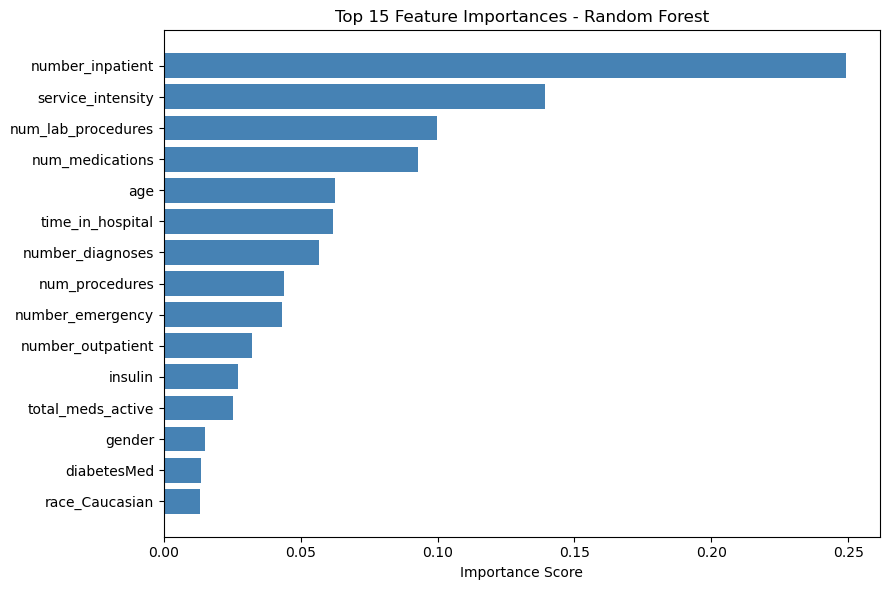

In [12]:
feature_names        = df.drop(columns=["readmitted"]).columns.tolist()
feature_importances  = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature"   : feature_names,
    "Importance": feature_importances
})

importance_df = importance_df.sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(9, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"], color="steelblue")
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()